# Sumário

[Funções de Ativação](#Funções-de-Ativação)

[Funções Auxiliares](#Funções-Auxiliares)

[Funções de Custo](#Funções-de-Custo)

[Inicialização de Pesos](#Inicialização-de-Pesos)

[Regularização](#Regularização)

[Learning Rate Decay](#Learning-Rate-Decay)

[Batch Normalization](#Batch-Normalization)

[Batch Generator](#Batch-Generator)

[Implementação](#Implementação)

[Testes da Implementação](#Testes-da-Implementação)

- [Exemplos do Notebook da Intuição](#Exemplos-do-Notebook-da-Intuição)

- [Regressão](#Regressão)
    - [Regressão Linear Simples](#Regressão-Linear-Simples---Exemplo-do-Perceptron)
    - [Regressão Linear Multivariada](#Regressão-Linear-Multivariada---Exerc%C3%ADcio-de-Regressão-do-Perceptron)
    - [Regressão Quadrática](#Regressão-Quadrática)
    - [Regressão Cúbica](#Regressão-Cúbica)
    - [Regressão Logarítimica](#Regressão-Logar%C3%ADtimica)
    - [Regressão Exponencial](#Regressão-Exponencial)

- [Classificação Binária](#Classificação-Binária)
    - [Porta AND/OR](#Porta-AND/OR)
    - [Porta XOR](#Porta-XOR)
    - [2 Clusters](#2-Clusters)
    - [4 Clusters](#4-Clusters)
    - [Círculos](#C%C3%ADrculos)
    - [Moons](#Moons)
    - [Espiral](#Espiral)
    
- [Classificação Multiclasse](#Classificação-Multiclasse)
    - [3 Clusters Multiclasse](#3-Clusters-Multiclasse)
    - [4 Clusters Multiclasse](#4-Clusters-Multiclasse)
    - [Espiral - 5 Classes](#Espiral---5-Classes)
    - [Make Classification - 4 Classes](#Make-Classification---4-Classes)
    - [Iris Dataset](#Iris-Dataset)

[Referências](#Referências)

# Imports and Configurações

In [1]:
import numpy as np
import _pickle as pkl
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.datasets import make_blobs, make_circles, make_moons, make_classification
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from utils import plot
from utils.samples_generator import make_spiral, make_square, make_cubic, make_exp, make_log10

%matplotlib inline

# Funções de Ativação

In [2]:
def linear(x, derivative=False):
    return np.ones_like(x) if derivative else x

def sigmoid(x, derivative=False):
    if derivative:
        y = sigmoid(x)
        return y*(1 - y)
    return 1.0/(1.0 + np.exp(-x))

def tanh(x, derivative=False):
    if derivative:
        y = tanh(x)
        return 1 - y**2
    return (np.exp(x) - np.exp(-x))/(np.exp(x) + np.exp(-x))

def relu(x, derivative=False):
    if derivative:
        return np.where(x <= 0, 0, 1)
    return np.maximum(0, x)

def leaky_relu(x, derivative=False):
    alpha = 0.1
    if derivative:
        return np.where(x <= 0, alpha, 1)
    return np.where(x <= 0, alpha*x, x)

def elu(x, derivative=False):
    alpha = 1.0
    if derivative:
        y = elu(x)
        return np.where(x <= 0, y + alpha, 1)
    return np.where(x <= 0, alpha*(np.exp(x) - 1), x)

# Funções Auxiliares

In [3]:
def softmax(x, y_oh=None, derivative=False):
    if derivative:
        y_pred = softmax(x)
        k = np.nonzero(y_pred * y_oh)
        pk = y_pred[k]
        y_pred[k] = pk * (1.0 - pk)
        return y_pred
    exp = np.exp(x)
    return exp / np.sum(exp, axis=1, keepdims=True)

# Funções de Custo

###### Para Regressão

In [4]:
def mae(y, y_pred, derivative=False):
    if derivative:
        return np.where(y_pred > y, 1, -1) / y.shape[0]
    return np.mean(np.abs(y - y_pred))

def mse(y, y_pred, derivative=False):
    if derivative:
        return -(y - y_pred) / y.shape[0]
    return 0.5 * np.mean((y - y_pred)**2)

###### Para Classificação Binária

In [5]:
def binary_cross_entropy(y, y_pred, derivative=False):
    if derivative:
        return -(y - y_pred)/(y_pred*(1-y_pred) * y.shape[0])
    return -np.mean(y*np.log(y_pred) + (1 - y)*np.log(1 - y_pred))

def sigmoid_cross_entropy(y, y_pred, derivative=False):
    y_sigmoid = sigmoid(y_pred)
    if derivative:
        return -(y - y_sigmoid) / y.shape[0]
    return -np.mean(y*np.log(y_sigmoid) + (1-y)*np.log(1-y_sigmoid))

###### Para Classificação Multiclasse

In [6]:
def neg_log_likelihood(y_oh, y_pred, derivative=False):
    k = np.nonzero(y_pred * y_oh)
    pk = y_pred[k]
    if derivative:
        y_pred[k] = (-1.0 / pk)
        return y_pred
    return np.mean(-np.log(pk))

def softmax_neg_log_likelihood(y_oh, y_pred, derivative=False):
    y_softmax = softmax(y_pred)
    if derivative:
        return -(y_oh - y_softmax) / y_oh.shape[0]    
    return neg_log_likelihood(y_oh, y_softmax)

# Inicialização de Pesos

In [7]:
def zeros(rows, cols):
    return np.zeros((rows, cols))

def ones(rows, cols):
    return np.ones((rows, cols))

def random_normal(rows, cols):
    return np.random.randn(rows, cols)

def random_uniform(rows, cols):
    return np.random.rand(rows, cols)

def glorot_normal(rows, cols):
    std_dev = np.sqrt(2.0 / (rows + cols))
    return std_dev * np.random.randn(rows, cols)

def glorot_uniform(rows, cols):
    limit = np.sqrt(6.0 / (rows + cols))
    return 2.0 * limit * np.random.rand(rows, cols) - limit

# Regularização

In [8]:
def l1_regularization(weights, derivative=False):
    if derivative:
        weights = [np.where(w < 0, -1, w) for w in weights]
        return np.array([no.where(w > 0, 1, w) for w in weights])
    return np.sum([np.sum(np.abs(w)) for w in weights])

def l2_regularization(weights, derivative=False):
    if derivative:
        return weights
    return 0.5 * np.sum(weights**2)

# Batch Generator

In [9]:
def batch_sequencial(x, y, batch_size=None):
    batch_size = x.shape[0] if batch_size is None else batch_size
    n_batches = x.shape[0] // batch_size

    for batch in range (n_batches):
        offset = batch_size * batch
        x_batch, y_batch = x[offset:offset+batch_size], y[offset:offset+batch_size]
        yield(x_batch, y_batch)

def batch_shuffle(x, y, batch_size=None):
    shuffle_index = np.random.permutation(range(x.shape[0]))
    return batch_sequencial(x[shuffle_index], y[shuffle_index], batch_size)                                     

# Learning Rate Decay

In [10]:
def none_decay(learning_rate, epoch, decay_rate, decay_steps=1):
    return learning_rate

def time_based_decay(learning_rate, epoch, decay_rate, decay_steps=1): #todos usando os mesmo parâmetro para terem uma interface comum, independente se vão usar ou  não.
    return 1.0 / (1.0 + decay_rate * epoch)

def exponencial_decay(learning_rate, epoch, decay_rate, decay_steps=1):
    return learning_rate * decay_rate ** epoch

def staircase_decay(learning_rate, epoch, decay_rate, decay_steps=1):
    return learning_rate * decay_rate ** (epoch//decay_steps)

# Batch Normalization 

In [11]:
def batchnorm_forward(layer, x, is_training=True):
    mu = np.mean(x, axis=0) if is_training else layer._pop_mean #mini-batch mean
    var = np.var(x, axis=0) if is_training else layer._pop_var #mini-batch variance
    x_norm = (x - mu) / np.sqrt(var + 1e-8) #normalize. 1e-8 to not divide by zero
    out = layer.gamma * x_norm + layer.beta
    
    if is_training:
        layer._pop_mean = layer.bn_decay*layer._pop_mean + (1.0-layer.bn_decay)*mu #média móvel
        layer._pop_var = layer.bn_decay*layer._pop_var + (1.0-layer.bn_decay)*var
        layer._bn_cache = (x, x_norm, mu, var)

    return out

def batchnorm_backward(layer, dactivation):
    x, x_norm, mu, var = layer._bn_cache

    m = layer._activ_inp.shape[0]
    x_mu = x - mu
    std_inv = 1.0 / np.sqrt(var + 1e-8)
    dx_norm = dactivation * layer.gamma
    dvar = np.sum(dx_norm * x_mu, axis=0) * -0.5 * (std_inv ** 3)
    dmu = np.sum(dx_norm * -std_inv, axis=0) + dvar * np.mean(-2.0 * x_mu, axis=0)

    dx = (dx_norm * std_inv) + (dvar * 2.0 * x_mu / m) + (dmu / m)
    layer._dgamma = np.sum(dactivation * x_norm, axis=0)
    layer._dbeta = np.sum(dactivation, axis=0)

    return dx

# Implementação 

In [12]:
class Layer():
    def __init__(self, input_dim, output_dim, weights_initializer=random_normal, biases_initializer=ones, activation=linear, dropout_prob=0.0, reg_func=l2_regularization, reg_strength=0.0, batch_norm=False, bn_decay=0.9, is_trainable=True): #construtor em python.
        self.input = None
        self.weights = weights_initializer(output_dim, input_dim)
        self.biases = biases_initializer(1, output_dim)
        self.activation = activation
        self.dropout_prob = dropout_prob
        self.reg_func = reg_func
        self.reg_strength = reg_strength
        self.batch_norm = batch_norm
        self.bn_decay = bn_decay
        self.gamma, self.beta = ones(1, output_dim), zeros(1, output_dim) #parametros do batch normalization
        self.is_trainable = is_trainable

        self._activ_inp, self._activ_out = None, None
        self._dweights, self._dbiases, self._prev_dweights = None, None, 0.0
        self._dropout_mask = None
        self._dgamma, self._dbeta = None, None
        self._pop_mean, self._pop_var = zeros(1, output_dim), zeros(1, output_dim) #batch normalization serve para estimar a média e o desvio padrão baseada no batch
        self._bn_cache = None

class NeuralNetwork():
    def __init__(self, cost_func=mse, learning_rate=1e-3, lr_decay_method=none_decay, lr_decay_rate=0.0, lr_decay_steps=1, momentum=0.0, patience=np.inf):
        self.layers = []
        self.cost_func = cost_func
        self.learning_rate = self.lr_initial = learning_rate
        self.lr_decay_method = lr_decay_method
        self.lr_decay_rate = lr_decay_rate
        self.lr_decay_steps = lr_decay_steps
        self.momentum = momentum
        self.patience, self.waiting = patience, 0
        self._best_model, self._best_loss = self.layers, np.inf

    def fit(self, x_train, y_train, x_val=None, y_val=None, epochs=100, verbose=10, batch_gen=batch_sequencial, batch_size=None): #sempre passo self para referenciar que estou no contexto dessa classe específica
        x_val, y_val = (x_train, y_train) if(x_val is None or y_val is None) else (x_val, y_val)
        
        for epoch in range(epochs+1):
            self.learning_rate = self.lr_decay_method(self.lr_initial, epoch, self.lr_decay_rate, self.lr_decay_steps) 
            for x_batch, y_batch in batch_gen(x_train, y_train, batch_size):
                y_pred = self.__feedforward(x_batch)
                self.__backprop(y_batch, y_pred)

            loss_val = self.cost_func(y_val, self.predict(x_val))
            if loss_val < self._best_loss:
                self._best_model, self._best_loss = self.layers, loss_val
                self.waiting = 0
            else:
                self.waiting += 1
                if self.waiting >= self.patience:
                    self.layers = self._best_model
                    return

            if epoch % verbose == 0:
                loss_train = self.cost_func(y_train, self.predict(x_train)) #não usei o y_pred, pq aqui os pesos iam vir desatualizados.
                loss_reg = (1.0 / y_train.shape[0]) * np.sum([layer.reg_strength * layer.reg_func(layer.weights) for layer in self.layers])
                print("epoch: {0:=4}/{1} loss_train: {2:.8f} + {3:.8f} = {4:.8f} loss_val = {5:.8f}".format(epoch, epochs, loss_train, loss_reg, loss_train+loss_reg, loss_val))
            
    def predict(self, x):
        return self.__feedforward(x, is_training=False)

    def save(self, file_path):
        pkl.dump(self, open(file_path, 'wb'), -1)

    def load(file_path):
        return pkl.load(open(file_path, 'rb'))

    def __feedforward(self, x, is_training=True): #python não tem motificadores de métodos para privado, esse __ ajuda a dificultar o acesso.
        self.layers[0].input = x
        for current_layer, next_layer in zip(self.layers, self.layers[1:] + [Layer(0,0)]): #coloque essa nova classe para não folhar nas iterações
            y = np.dot(current_layer.input, current_layer.weights.T) + current_layer.biases
            y = batchnorm_forward(current_layer, y, is_training) if current_layer.batch_norm else y
            current_layer._dropout_mask = np.random.binomial(1, 1.0 - current_layer.dropout_prob, y.shape) / (1.0 - current_layer.dropout_prob)
            current_layer._activ_inp = y
            current_layer._activ_out = next_layer.input = current_layer.activation(y) * (current_layer._dropout_mask if is_training else 1.0)
        return self.layers[-1]._activ_out
            
    def __backprop(self, y, y_pred):
        last_delta = self.cost_func(y, y_pred, derivative=True)
        for layer in reversed(self.layers):
            dactivation = layer.activation(layer._activ_inp, derivative=True) * last_delta * layer._dropout_mask
            dactivation = batchnorm_backward(layer, dactivation) if layer.batch_norm else dactivation
            last_delta = np.dot(dactivation, layer.weights)
            layer._dweights = np.dot(dactivation.T, layer.input)
            layer._dbiases = 1.0 * dactivation.sum(axis=0, keepdims=True)

        for layer in reversed(self.layers):
            if layer.is_trainable:
                layer._dweight = layer._dweights + (1.0 / y.shape[0]) * layer.reg_strength * layer.reg_func(layer.weights, derivative=True)
                layer._prev_dweights = -self.learning_rate * layer._dweights + self.momentum * layer._prev_dweights
                layer.weights = layer.weights + layer._prev_dweights
                layer.biases = layer.biases - self.learning_rate * layer._dbiases
                if layer.batch_norm:
                    layer.gamma = layer.gamma - self.learning_rate * layer._dgamma
                    layer.beta = layer.beta - self.learning_rate * layer._dbeta

In [15]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

x, y = make_regression(n_samples=100, n_features=1, n_informative=2, noise=10.0, random_state=42)
x, y = x.reshape(-1, 1), y.reshape(-1, 1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

nn = NeuralNetwork(cost_func=mse, learning_rate=1e-1, patience=10)
nn.layers.append(Layer(input_dim=x.shape[1], output_dim=y.shape[1], activation=linear))

nn.fit(x_train, y_train, x_val=x_test, y_val=y_test, epochs=1000, verbose=50)

epoch:    0/1000 loss_train: 723.49758031 loss_val = 761.40927375
epoch:   50/1000 loss_train: 35.45638166 loss_val = 53.38101183
epoch:  100/1000 loss_train: 35.23225058 loss_val = 51.77215104
epoch:  150/1000 loss_train: 35.23214680 loss_val = 51.73730075
epoch:  200/1000 loss_train: 35.23214675 loss_val = 51.73653051
epoch:  250/1000 loss_train: 35.23214675 loss_val = 51.73651379
epoch:  300/1000 loss_train: 35.23214675 loss_val = 51.73651343
epoch:  350/1000 loss_train: 35.23214675 loss_val = 51.73651342
epoch:  400/1000 loss_train: 35.23214675 loss_val = 51.73651342
not improving! [1] current: 51.736513417194146 best: 51.736513417194146
not improving! [1] current: 51.73651341719403 best: 51.73651341719403
not improving! [1] current: 51.73651341719398 best: 51.73651341719398
not improving! [1] current: 51.73651341719394 best: 51.73651341719393
not improving! [1] current: 51.736513417193926 best: 51.736513417193926
not improving! [1] current: 51.73651341719389 best: 51.7365134171938

## Exemplos do Notebook da Intuição

### Exemplo 1

In [18]:
x = np.array([[0.05, 0.10]])
y = np.array([[0.01, 0.99]])

w1 = np.array([[0.15, 0.20], [0.25, 0.30]])
b1 = np.array([[0.35]]) 
w2 = np.array([[0.40, 0.45], [0.50, 0.55]])
b2 = np.array([[0.60]])

# insira sua rede aqui!
input_dim, output_dim = x.shape[1], y.shape[1]
nn = NeuralNetwork(cost_func=mse, learning_rate=0.5)
nn.layers.append(Layer(input_dim=input_dim, output_dim=2, activation=sigmoid))
nn.layers.append(Layer(input_dim=2, output_dim=output_dim, activation=sigmoid))

nn.layers[0].weights = w1
nn.layers[0].biases = b1
nn.layers[1].weights = w2
nn.layers[1].biases = b2

nn.fit(x, y, epochs=0, verbose=1)

for layer in nn.layers:
    print(layer.weights)

nn.save('model.pkl')

epoch:    0/0 loss_train: 0.14023572 + 0.00000000 = 0.14023572 loss_val = 0.14023572
[[0.14978072 0.19956143]
 [0.24975114 0.29950229]]
[[0.35891648 0.40866619]
 [0.51130127 0.56137012]]


In [13]:
nn = NeuralNetwork.load('model.pkl')
for layer in nn.layers:
    print(layer.weights)

[[0.14978072 0.19956143]
 [0.24975114 0.29950229]]
[[0.35891648 0.40866619]
 [0.51130127 0.56137012]]


### Exemplo 2

In [27]:
x = np.array([[0.1, 0.2, 0.7]])
y = np.array([[1, 0, 0]])
D_in, D_out = x.shape[1], y.shape[1]

w1 = np.array([[0.1, 0.2, 0.3], [0.3, 0.2, 0.7], [0.4, 0.3, 0.9]])
b1 = np.ones((1,3))
w2 = np.array([[0.2, 0.3, 0.5], [0.3, 0.5, 0.7], [0.6, 0.4, 0.8]])
b2 = np.ones((1,3))
w3 = np.array([[0.1, 0.4, 0.8], [0.3, 0.7, 0.2], [0.5, 0.2, 0.9]])
b3 = np.ones((1,3))

# insira sua rede aqui!
nn = NeuralNetwork(cost_func=softmax_neg_log_likelihood, learning_rate=0.01)
nn.layers.append(Layer(input_dim=D_in, output_dim=3, activation=relu))
nn.layers.append(Layer(input_dim=3, output_dim=3, activation=sigmoid))
nn.layers.append(Layer(input_dim=3, output_dim=D_out, activation=linear))

for i, w, b in zip(range(3), [w1, w2, w3], [b1, b2, b3]):
    nn.layers[i].weights = w
    nn.layers[i].biases = b

nn.fit(x, y, epochs=300, verbose=30)

for layer in nn.layers:
    print(layer.weights)

epoch:    0/300 loss_train: 1.14054966
epoch:   30/300 loss_train: 0.59630022
epoch:   60/300 loss_train: 0.36031189
epoch:   90/300 loss_train: 0.24668884
epoch:  120/300 loss_train: 0.18386202
epoch:  150/300 loss_train: 0.14510157
epoch:  180/300 loss_train: 0.11918285
epoch:  210/300 loss_train: 0.10078511
epoch:  240/300 loss_train: 0.08712037
epoch:  270/300 loss_train: 0.07660623
epoch:  300/300 loss_train: 0.06828531
[[0.10083595 0.2016719  0.30585165]
 [0.30086971 0.20173942 0.70608796]
 [0.40145052 0.30290104 0.91015363]]
[[0.20544723 0.30673159 0.50749567]
 [0.30994562 0.5123005  0.71366784]
 [0.61065514 0.41317913 0.81464085]]
[[ 0.66465527  0.98758148  1.39393956]
 [ 0.05020341  0.44006253 -0.06274803]
 [ 0.18514132 -0.12764401  0.56880846]]


## Gradient Checking

In [69]:
def __compute_approx_grads(nn, x, y, eps=1e-4):
    approx_grads=[]
    feed_forward = lambda inp: nn._NeuralNetwork__feedforward(inp, is_training=True)

    for layer in nn.layers:
        assert(layer.dropout_prob == 0), "o gradiente checking não pode ser aplicado em redes de DROPOUT" 
        
        w_ori = layer.weights.copy()
        w_ravel = w_ori.ravel() #de bidimendional pra uni
        w_shape = w_ori.shape

        for i in range(w_ravel.size):
            w_plus = w_ravel.copy()
            w_plus[i] += eps
            layer.weights = w_plus.reshape(w_shape)
            J_plus = nn.cost_func(y, feed_forward(x)) + ((1.0 / y.shape[0]) * layer.reg_strength * layer.reg_func(layer.weights))

            w_minus = w_ravel.copy()
            w_minus[i] -= eps
            layer.weights = w_minus.reshape(w_shape)
            J_minus = nn.cost_func(y, feed_forward(x)) + ((1.0 / y.shape[0]) * layer.reg_strength * layer.reg_func(layer.weights))

            approx_grads.append((J_plus - J_minus) / (2*eps))
        layer.weights = w_ori
    return approx_grads

def gradient_checking(nn, x, y, eps=1e-4, verbose=False, verbose_precision=5):
    from copy import deepcopy
    nn_copy = deepcopy(nn)

    nn.fit(x, y, epochs=0)
    grads = np.concatenate([layer._dweights.ravel() for layer in nn.layers])

    approx_grads = __compute_approx_grads(nn_copy, x, y, eps)

    is_close = np.allclose(grads, approx_grads)
    print("{}".format("033[92mGRADIENTS OK" if is_close else "033[91mGRADIENTS FAIL"))

    norm_num = np.linalg.norm(grads - approx_grads)
    norm_den = np.linalg.norm(grads) + np.linalg.norm(approx_grads)
    error = norm_num / norm_den
    print("relative error:", error)

    if verbose:
        np.set_printoptions(precision=verbose_precision, linewidth=200, suppress=True)
        print("gradientes:", grads)
        print("Aproximado:", np.array(approx_grads))

In [70]:
np.random.seed(1234)
N, D = 100, 2
x = np.random.rand(N, D)

In [68]:
y = np.random.rand(N, 1)

nn = NeuralNetwork(cost_func=mse, learning_rate=1e-2)
nn.layers.append(Layer(input_dim=x.shape[1], output_dim=4, activation=relu))
nn.layers.append(Layer(input_dim=4, output_dim=1, activation=tanh))
nn.layers.append(Layer(input_dim=1, output_dim=2, activation=sigmoid))
nn.layers.append(Layer(input_dim=2, output_dim=5, activation=leaky_relu))
nn.layers.append(Layer(input_dim=5, output_dim=3, activation=elu))
nn.layers.append(Layer(input_dim=3, output_dim=y.shape[1], activation=linear))

nn.fit(x, y, epochs=100)
gradient_checking(nn, x, y, eps=1e-4, verbose=True)

epoch:    0/100 loss_train: 0.04190510 + 0.00000000 = 0.04190510 loss_val = 0.04190510
epoch:   10/100 loss_train: 0.03927721 + 0.00000000 = 0.03927721 loss_val = 0.03927721
epoch:   20/100 loss_train: 0.03927699 + 0.00000000 = 0.03927699 loss_val = 0.03927699
epoch:   30/100 loss_train: 0.03927699 + 0.00000000 = 0.03927699 loss_val = 0.03927699
epoch:   40/100 loss_train: 0.03927699 + 0.00000000 = 0.03927699 loss_val = 0.03927699
epoch:   50/100 loss_train: 0.03927699 + 0.00000000 = 0.03927699 loss_val = 0.03927699
epoch:   60/100 loss_train: 0.03927699 + 0.00000000 = 0.03927699 loss_val = 0.03927699
epoch:   70/100 loss_train: 0.03927699 + 0.00000000 = 0.03927699 loss_val = 0.03927699
epoch:   80/100 loss_train: 0.03927699 + 0.00000000 = 0.03927699 loss_val = 0.03927699
epoch:   90/100 loss_train: 0.03927699 + 0.00000000 = 0.03927699 loss_val = 0.03927699
epoch:  100/100 loss_train: 0.03927699 + 0.00000000 = 0.03927699 loss_val = 0.03927699
epoch:    0/0 loss_train: 0.03927699 + 0.00

In [73]:
y = np.random.randint(0, 2, (N, 1))

nn = NeuralNetwork(cost_func=sigmoid_cross_entropy, learning_rate=1e-2)
nn.layers.append(Layer(input_dim=x.shape[1], output_dim=4, activation=relu))
nn.layers.append(Layer(input_dim=4, output_dim=1, activation=tanh))
nn.layers.append(Layer(input_dim=1, output_dim=2, activation=sigmoid))
nn.layers.append(Layer(input_dim=2, output_dim=5, activation=leaky_relu))
nn.layers.append(Layer(input_dim=5, output_dim=3, activation=elu))
nn.layers.append(Layer(input_dim=3, output_dim=y.shape[1], activation=linear))

nn.fit(x, y, epochs=100)
gradient_checking(nn, x, y, eps=1e-4, verbose=True)

epoch:    0/100 loss_train: 5.38766912 + 0.00000000 = 5.38766912 loss_val = 5.38766912
epoch:   10/100 loss_train: 3.09339329 + 0.00000000 = 3.09339329 loss_val = 3.09339329
epoch:   20/100 loss_train: 1.71492925 + 0.00000000 = 1.71492925 loss_val = 1.71492925
epoch:   30/100 loss_train: 1.00098532 + 0.00000000 = 1.00098532 loss_val = 1.00098532
epoch:   40/100 loss_train: 0.76031387 + 0.00000000 = 0.76031387 loss_val = 0.76031387
epoch:   50/100 loss_train: 0.70229871 + 0.00000000 = 0.70229871 loss_val = 0.70229871
epoch:   60/100 loss_train: 0.68953650 + 0.00000000 = 0.68953650 loss_val = 0.68953650
epoch:   70/100 loss_train: 0.68673460 + 0.00000000 = 0.68673460 loss_val = 0.68673460
epoch:   80/100 loss_train: 0.68611362 + 0.00000000 = 0.68611362 loss_val = 0.68611362
epoch:   90/100 loss_train: 0.68597507 + 0.00000000 = 0.68597507 loss_val = 0.68597507
epoch:  100/100 loss_train: 0.68594405 + 0.00000000 = 0.68594405 loss_val = 0.68594405
epoch:    0/0 loss_train: 0.68594280 + 0.00

In [81]:
y = np.random.randint(0, 3, (N, 1))
y_oh = OneHotEncoder(sparse_output=False).fit_transform(y)

nn = NeuralNetwork(cost_func=softmax_neg_log_likelihood, learning_rate=1e-3)
nn.layers.append(Layer(input_dim=x.shape[1], output_dim=4, activation=relu))
nn.layers.append(Layer(input_dim=4, output_dim=1, activation=tanh))
nn.layers.append(Layer(input_dim=1, output_dim=2, activation=sigmoid))
nn.layers.append(Layer(input_dim=2, output_dim=5, activation=leaky_relu))
nn.layers.append(Layer(input_dim=5, output_dim=3, activation=elu))
nn.layers.append(Layer(input_dim=3, output_dim=y_oh.shape[1], activation=linear))

nn.fit(x, y, epochs=100)
gradient_checking(nn, x, y_oh, eps=1e-4, verbose=True)

epoch:    0/100 loss_train: 2.01205390 + 0.00000000 = 2.01205390 loss_val = 2.01205390
epoch:   10/100 loss_train: 1.83725718 + 0.00000000 = 1.83725718 loss_val = 1.83725718
epoch:   20/100 loss_train: 1.69158655 + 0.00000000 = 1.69158655 loss_val = 1.69158655
epoch:   30/100 loss_train: 1.57218286 + 0.00000000 = 1.57218286 loss_val = 1.57218286
epoch:   40/100 loss_train: 1.47577572 + 0.00000000 = 1.47577572 loss_val = 1.47577572
epoch:   50/100 loss_train: 1.39894612 + 0.00000000 = 1.39894612 loss_val = 1.39894612
epoch:   60/100 loss_train: 1.33837816 + 0.00000000 = 1.33837816 loss_val = 1.33837816
epoch:   70/100 loss_train: 1.29104398 + 0.00000000 = 1.29104398 loss_val = 1.29104398
epoch:   80/100 loss_train: 1.25430608 + 0.00000000 = 1.25430608 loss_val = 1.25430608
epoch:   90/100 loss_train: 1.22594860 + 0.00000000 = 1.22594860 loss_val = 1.22594860
epoch:  100/100 loss_train: 1.20415975 + 0.00000000 = 1.20415975 loss_val = 1.20415975
epoch:    0/0 loss_train: 1.19949363 + 0.00

## Regressão

### Regressão Linear Simples - Exemplo do Perceptron

(100, 2)
(100, 1) (100, 1)


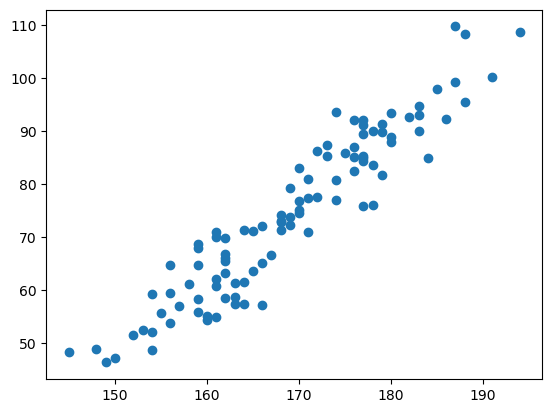

In [28]:
data = np.loadtxt('data/medidas.csv', delimiter=',', skiprows=1)
print(data.shape)

x, y = data[:,0].reshape(-1,1), data[:,1].reshape(-1,1)
print(x.shape, y.shape)
plt.scatter(x, y)

-1.0 0.9999999999999991


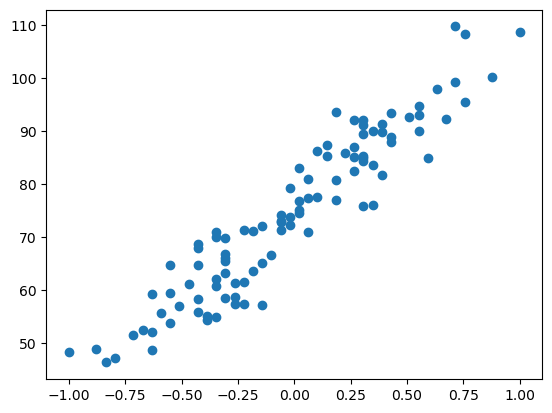

In [29]:
minmax = MinMaxScaler(feature_range=(-1, 1))
x = minmax.fit_transform(x.astype(np.float64))

print(x.min(), x.max())
plt.scatter(x, y)

epoch:    0/1000 loss_train: 2336.93563766
epoch:  100/1000 loss_train: 15.90100978
epoch:  200/1000 loss_train: 13.10714627
epoch:  300/1000 loss_train: 13.04296624
epoch:  400/1000 loss_train: 13.04149191
epoch:  500/1000 loss_train: 13.04145804
epoch:  600/1000 loss_train: 13.04145726
epoch:  700/1000 loss_train: 13.04145724
epoch:  800/1000 loss_train: 13.04145724
epoch:  900/1000 loss_train: 13.04145724
epoch: 1000/1000 loss_train: 13.04145724
[[33.60164743]]
[[74.99636286]]


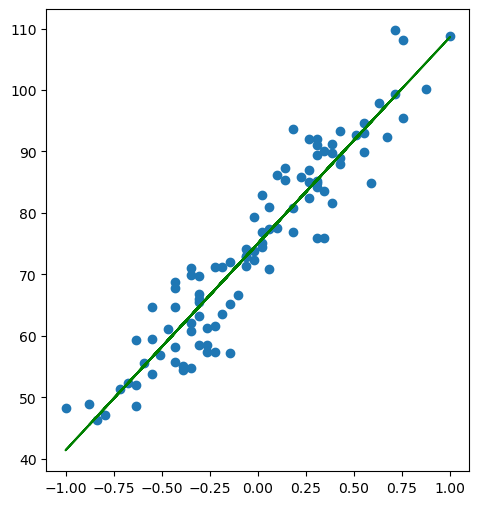

In [31]:
input_dim, output_dim = x.shape[1], y.shape[1]

# insira sua rede aqui!
nn = NeuralNetwork(cost_func=mse, learning_rate=1e-1)
nn.layers.append(Layer(input_dim=input_dim, output_dim=output_dim, activation=linear)) #perceptron

nn.fit(x, y, epochs=1000, verbose=100)

print(nn.layers[0].weights)
print(nn.layers[0].biases)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(x, y)
plt.plot(x, nn.predict(x), c='green')

### Regressão Linear Multivariada - Exercício de Regressão do Perceptron

In [32]:
data = np.loadtxt('data/notas.csv', delimiter=',', skiprows=1)
print(data.shape)

x, y = data[:,:-1], data[:,-1].reshape(-1,1)
print(x.shape, y.shape)

(25, 4)
(25, 3) (25, 1)


In [34]:
minmax = MinMaxScaler(feature_range=(-1, 1))
x = minmax.fit_transform(x.astype(np.float64))

print(x.min(axis=0), x.max(axis=0))

[-1. -1. -1.] [1. 1. 1.]


In [35]:
input_dim, output_dim = x.shape[1], y.shape[1]

# insira sua rede aqui!
nn = NeuralNetwork(cost_func=mse, learning_rate=1e-1)
nn.layers.append(Layer(input_dim=input_dim, output_dim=output_dim, activation=linear))
nn.fit(x, y, epochs=2000, verbose=200)

print(nn.layers[0].weights)
print(nn.layers[0].biases)

epoch:    0/2000 loss_train: 9991.05973847
epoch:  200/2000 loss_train: 6.53136845
epoch:  400/2000 loss_train: 3.95709769
epoch:  600/2000 loss_train: 3.23003914
epoch:  800/2000 loss_train: 3.00149136
epoch: 1000/2000 loss_train: 2.92142458
epoch: 1200/2000 loss_train: 2.89075603
epoch: 1400/2000 loss_train: 2.87826051
epoch: 1600/2000 loss_train: 2.87297379
epoch: 1800/2000 loss_train: 2.87068899
epoch: 2000/2000 loss_train: 2.86969018
[[ 8.94412153 13.97190765 26.172261  ]]
[[150.6379008]]


### Regressão Quadrática

(100, 1) (100, 1)


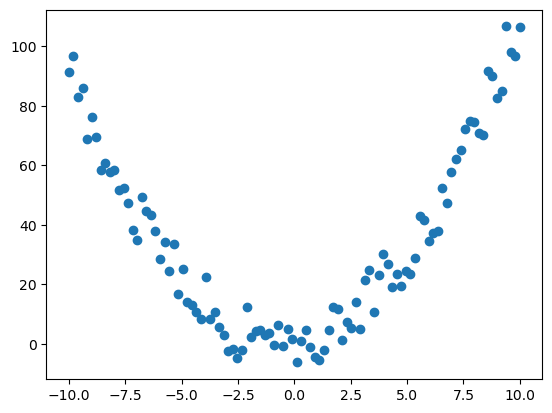

In [10]:
x, y = make_square(n_samples=100, x_min=-10, x_max=10, a=1, b=1, c=1, noise=10)


print(x.shape, y.shape)
plt.scatter(x, y)

In [11]:
minmax = MinMaxScaler(feature_range=(-1, 1))
x = minmax.fit_transform(x.astype(np.float64))

print(x.min(axis=0), x.max(axis=0))

[-1.] [1.]


epoch:    0/5000 loss_train: 1023.06758931
epoch:  500/5000 loss_train: 71.29828591
epoch: 1000/5000 loss_train: 39.22367058
epoch: 1500/5000 loss_train: 29.13895327
epoch: 2000/5000 loss_train: 24.19107734
epoch: 2500/5000 loss_train: 22.19543251
epoch: 3000/5000 loss_train: 21.23164686
epoch: 3500/5000 loss_train: 20.49716610
epoch: 4000/5000 loss_train: 19.87971707
epoch: 4500/5000 loss_train: 19.09391967
epoch: 5000/5000 loss_train: 18.35485375


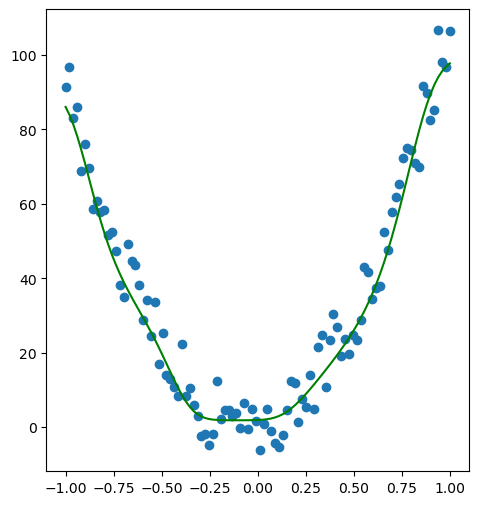

In [21]:
input_dim, output_dim = x.shape[1], y.shape[1]

# insira sua rede aqui!
nn = NeuralNetwork(cost_func=mse, learning_rate=1e-3, momentum=0.9)
nn.layers.append(Layer(input_dim=input_dim, output_dim=10, activation=tanh))
nn.layers.append(Layer(input_dim=10, output_dim=10, activation=tanh))
nn.layers.append(Layer(input_dim=10, output_dim=output_dim, activation=linear))

nn.fit(x, y, epochs=5000, verbose=500)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(x, y)
plt.plot(x, nn.predict(x), c='green')

### Regressão Cúbica

(100, 1) (100, 1)


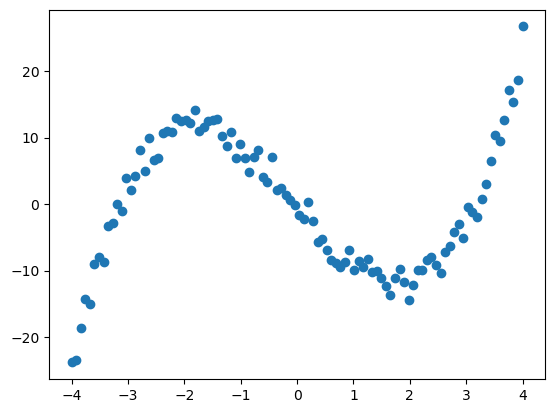

In [17]:
x, y = make_cubic(n_samples=100, x_min=-4, x_max=4, a=1, b=0, c=-10, d=0, noise=3)

print(x.shape, y.shape)
plt.scatter(x, y)

In [19]:
minmax = MinMaxScaler(feature_range=(-1, 1))
x = minmax.fit_transform(x.astype(np.float64))

print(x.min(axis=0), x.max(axis=0))

[-1.] [1.]


epoch:    0/5000 loss_train: 61.42229703
epoch:  100/5000 loss_train: 20.58307974
epoch:  200/5000 loss_train: 15.60902559
epoch:  300/5000 loss_train: 8.62795983
epoch:  400/5000 loss_train: 11.19591798
epoch:  500/5000 loss_train: 5.65106453
epoch:  600/5000 loss_train: 4.83831176
epoch:  700/5000 loss_train: 5.49275425
epoch:  800/5000 loss_train: 4.26919689
epoch:  900/5000 loss_train: 5.68805376
epoch: 1000/5000 loss_train: 4.24771633
epoch: 1100/5000 loss_train: 5.45743271
epoch: 1200/5000 loss_train: 4.60787277
epoch: 1300/5000 loss_train: 6.95068301
epoch: 1400/5000 loss_train: 3.84374615
epoch: 1500/5000 loss_train: 3.21469808
epoch: 1600/5000 loss_train: 5.64303136
epoch: 1700/5000 loss_train: 3.29434995
epoch: 1800/5000 loss_train: 4.59060921
epoch: 1900/5000 loss_train: 2.80108179
epoch: 2000/5000 loss_train: 3.81934360
epoch: 2100/5000 loss_train: 2.80154261
epoch: 2200/5000 loss_train: 4.47641791
epoch: 2300/5000 loss_train: 3.61318188
epoch: 2400/5000 loss_train: 3.20328

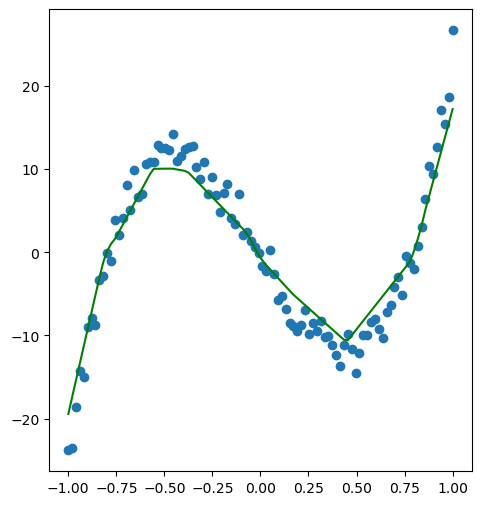

In [22]:
input_dim, output_dim = x.shape[1], y.shape[1]

nn = NeuralNetwork(cost_func=mse, learning_rate=1e-2)
nn.layers.append(Layer(input_dim=input_dim, output_dim=10, activation=relu))
nn.layers.append(Layer(input_dim=10, output_dim=10, activation=relu))
nn.layers.append(Layer(input_dim=10, output_dim=output_dim, activation=linear))

nn.fit(x, y, epochs=5000, verbose=100) 

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(x, y)
plt.plot(x, nn.predict(x), c='green')

### Regressão Logarítimica

(100, 1) (100, 1)


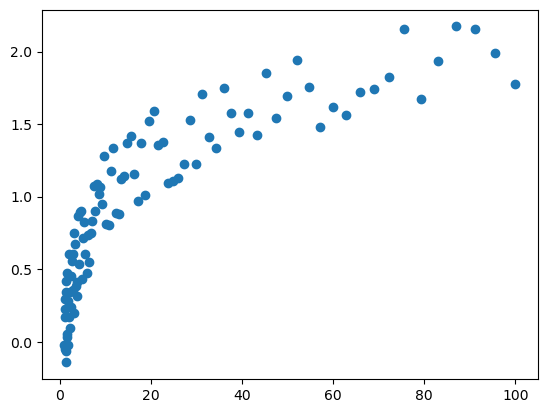

In [26]:
x, y = make_log10(n_samples=100, x_min=1, x_max=100, noise=0.3)

print(x.shape, y.shape)
plt.scatter(x, y)

In [30]:
minmax = MinMaxScaler(feature_range=(-1, 1))
x = minmax.fit_transform(x.astype(np.float64))

print(x.min(axis=0), x.max(axis=0))

[-1.] [1.]


epoch:    0/5000 loss_train: 0.19968317
epoch:  500/5000 loss_train: 0.02583067
epoch: 1000/5000 loss_train: 0.02195027
epoch: 1500/5000 loss_train: 0.01958418
epoch: 2000/5000 loss_train: 0.01846779
epoch: 2500/5000 loss_train: 0.01784456
epoch: 3000/5000 loss_train: 0.01751436
epoch: 3500/5000 loss_train: 0.01722486
epoch: 4000/5000 loss_train: 0.01708631
epoch: 4500/5000 loss_train: 0.01701046
epoch: 5000/5000 loss_train: 0.01696031


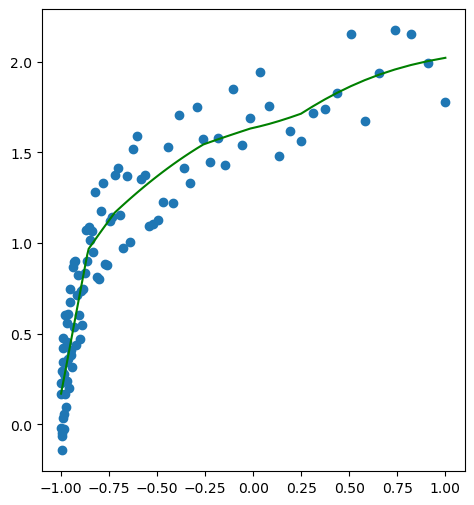

In [45]:
input_dim, output_dim = x.shape[1], y.shape[1]

nn = NeuralNetwork(cost_func=mse, learning_rate=1e-1)
nn.layers.append(Layer(input_dim=input_dim, output_dim=10, activation=relu))
nn.layers.append(Layer(input_dim=10, output_dim=10, activation=sigmoid))
nn.layers.append(Layer(input_dim=10, output_dim=output_dim, activation=linear))
nn.fit(x, y, epochs=5000, verbose=500)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(x, y)
plt.plot(x, nn.predict(x), c='green')

### Regressão Exponencial

(100, 1) (100, 1)


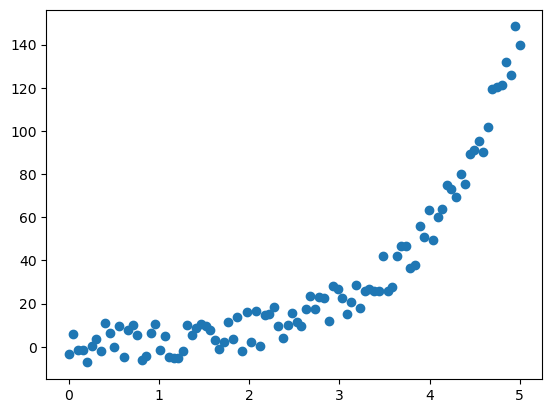

In [46]:
x, y = make_exp(n_samples=100, x_min=0, x_max=5, noise=10)

print(x.shape, y.shape)
plt.scatter(x, y)

In [51]:
minmax = MinMaxScaler(feature_range=(-1, 1))
x = minmax.fit_transform(x.astype(np.float64))

print(x.min(axis=0), x.max(axis=0))

[-1.] [1.]


epoch:    0/10000 loss_train: 728.92642706
epoch:  500/10000 loss_train: 24.03756154
epoch: 1000/10000 loss_train: 14.47417694
epoch: 1500/10000 loss_train: 14.51454428
epoch: 2000/10000 loss_train: 14.10087827
epoch: 2500/10000 loss_train: 13.72684146
epoch: 3000/10000 loss_train: 14.65375363
epoch: 3500/10000 loss_train: 12.03090394
epoch: 4000/10000 loss_train: 14.22813751
epoch: 4500/10000 loss_train: 12.83187976
epoch: 5000/10000 loss_train: 12.87177061
epoch: 5500/10000 loss_train: 12.45805918
epoch: 6000/10000 loss_train: 13.34500663
epoch: 6500/10000 loss_train: 12.04079772
epoch: 7000/10000 loss_train: 11.26108025
epoch: 7500/10000 loss_train: 11.57397636
epoch: 8000/10000 loss_train: 11.11260517
epoch: 8500/10000 loss_train: 10.68491286
epoch: 9000/10000 loss_train: 10.54992807
epoch: 9500/10000 loss_train: 10.44148947
epoch: 10000/10000 loss_train: 10.35117424


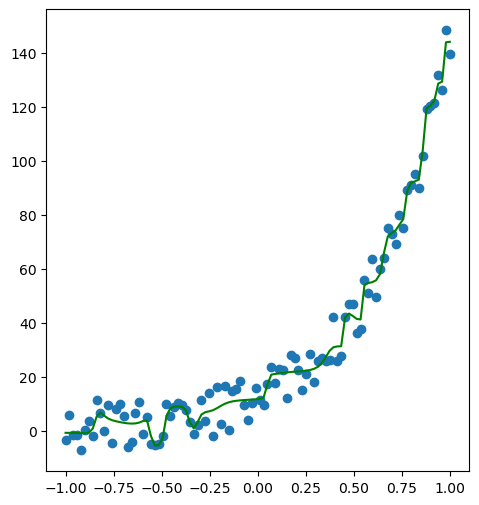

In [104]:
input_dim, output_dim = x.shape[1], y.shape[1]

# insira sua rede aqui!
nn = NeuralNetwork(cost_func=mse, learning_rate=1e-1)
nn.layers.append(Layer(input_dim=input_dim, output_dim=20, activation=tanh))
nn.layers.append(Layer(input_dim=20, output_dim=20, activation=sigmoid))
nn.layers.append(Layer(input_dim=20, output_dim=output_dim, activation=linear))
nn.fit(x, y, epochs=10000, verbose=500)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(x, y)
plt.plot(x, nn.predict(x), c='green')

## Classificação Binária

### Porta AND/OR

(4, 2) (4, 1)


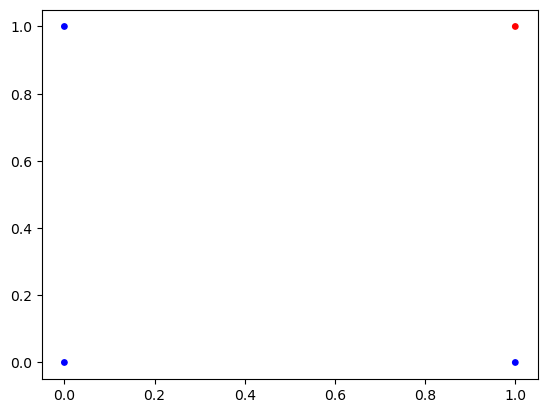

In [9]:
x = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 0, 0, 1]).reshape(-1, 1)

print(x.shape, y.shape)
plt.scatter(x[:,0], x[:,1], c=list(np.array(y).ravel()), s=15, cmap='bwr')

epoch:    0/100 loss_train: 0.62995088
epoch:   10/100 loss_train: 0.41379248
epoch:   20/100 loss_train: 0.33334707
epoch:   30/100 loss_train: 0.28130669
epoch:   40/100 loss_train: 0.24436092
epoch:   50/100 loss_train: 0.21646013
epoch:   60/100 loss_train: 0.19447816
epoch:   70/100 loss_train: 0.17662511
epoch:   80/100 loss_train: 0.16179185
epoch:   90/100 loss_train: 0.14924783
epoch:  100/100 loss_train: 0.13848838
Predições:
[[0.00750703]
 [0.14518075]
 [0.1455546 ]
 [0.79274772]]
Acurácia: 100.00%


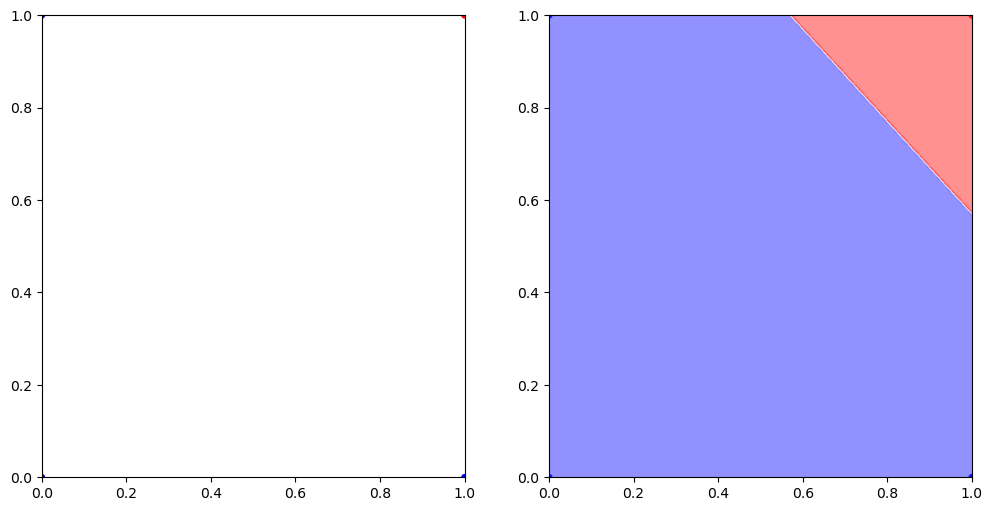

In [17]:
input_dim, output_dim = x.shape[1], y.shape[1]

# insira sua rede aqui!
nn = NeuralNetwork(cost_func=binary_cross_entropy, learning_rate=1.0)
nn.layers.append(Layer(input_dim=input_dim, output_dim=output_dim, activation=sigmoid))
nn.fit(x, y, epochs=100, verbose=10)

y_pred = nn.predict(x)
print('Predições:', y_pred, sep='\n')
print('Acurácia: {:.2f}%'.format(100*accuracy_score(y, y_pred > 0.5)))

plot.classification_predictions(x, y, is_binary=True, nn=nn, threshold=0.5, cmap='bwr')

### Porta XOR

(4, 2) (4, 1)


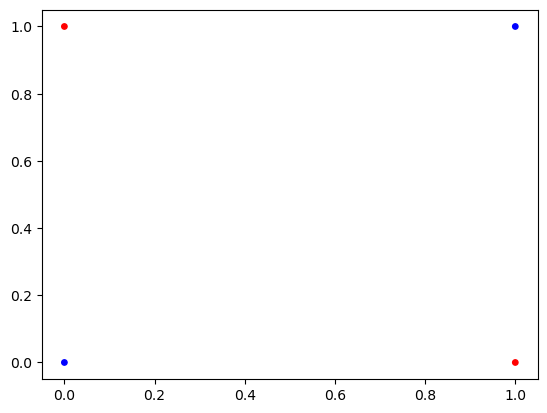

In [18]:
x = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0]).reshape(-1, 1)

print(x.shape, y.shape)
plt.scatter(x[:,0], x[:,1], c=list(np.array(y).ravel()), s=15, cmap='bwr')

epoch:    0/2000 loss_train: 0.82908366
epoch:  100/2000 loss_train: 0.61112693
epoch:  200/2000 loss_train: 0.49871028
epoch:  300/2000 loss_train: 0.34973261
epoch:  400/2000 loss_train: 0.11624591
epoch:  500/2000 loss_train: 0.05799658
epoch:  600/2000 loss_train: 0.03754386
epoch:  700/2000 loss_train: 0.02750812
epoch:  800/2000 loss_train: 0.02161643
epoch:  900/2000 loss_train: 0.01776234
epoch: 1000/2000 loss_train: 0.01505298
epoch: 1100/2000 loss_train: 0.01304820
epoch: 1200/2000 loss_train: 0.01150680
epoch: 1300/2000 loss_train: 0.01028594
epoch: 1400/2000 loss_train: 0.00929574
epoch: 1500/2000 loss_train: 0.00847691
epoch: 1600/2000 loss_train: 0.00778881
epoch: 1700/2000 loss_train: 0.00720264
epoch: 1800/2000 loss_train: 0.00669745
epoch: 1900/2000 loss_train: 0.00625765
epoch: 2000/2000 loss_train: 0.00587140
Predições:
[[0.0072184 ]
 [0.9947287 ]
 [0.99469399]
 [0.00561978]]
Acurácia: 100.00%


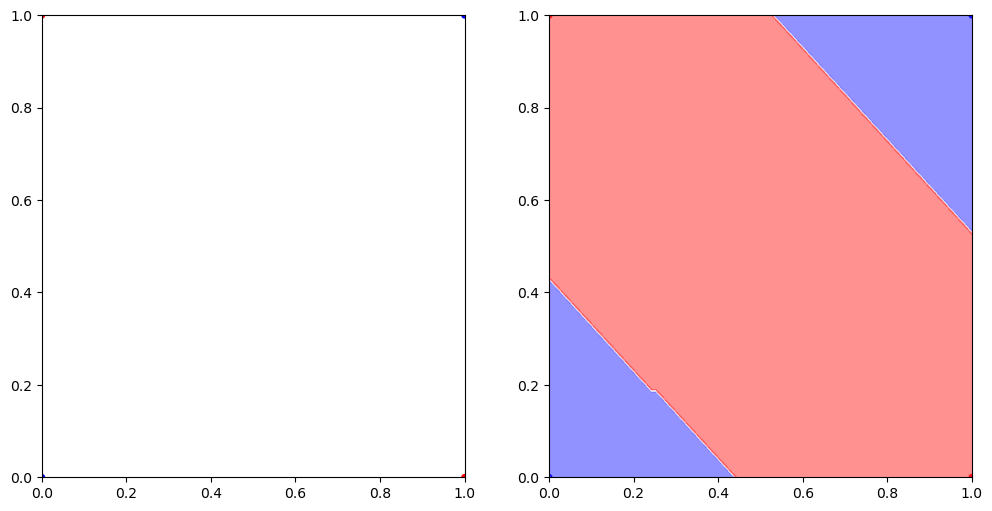

In [31]:
input_dim, output_dim = x.shape[1], y.shape[1]

# insira sua rede aqui!
nn = NeuralNetwork(cost_func=binary_cross_entropy, learning_rate=1.0)
nn.layers.append(Layer(input_dim=input_dim, output_dim=2, activation=sigmoid))
nn.layers.append(Layer(input_dim=2, output_dim=output_dim, activation=sigmoid))

nn.fit(x, y, epochs=1000, verbose=100)

y_pred = nn.predict(x)
print('Predições:', y_pred, sep='\n')
print('Acurácia: {:.2f}%'.format(100*accuracy_score(y, y_pred > 0.5)))

plot.classification_predictions(x, y, is_binary=True, nn=nn, threshold=0.5, cmap='bwr')

### 2 Clusters

(100, 2) (100, 1)


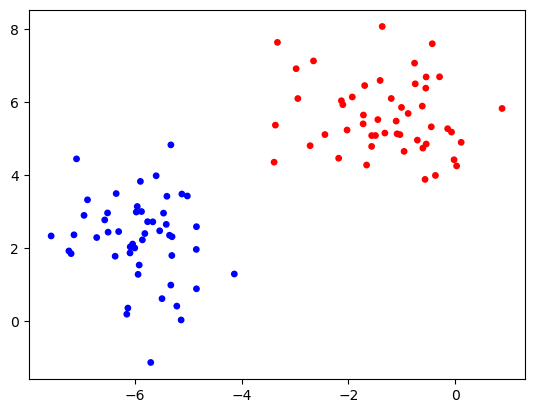

In [32]:
x, y = make_blobs(n_samples=100, n_features=2, centers=2, random_state=1234)
y = y.reshape(-1, 1)

print(x.shape, y.shape)
plt.scatter(x[:,0], x[:,1], c=list(np.array(y).ravel()), s=15, cmap='bwr')

epoch:    0/1000 loss_train: 2.77698681
epoch:  100/1000 loss_train: 0.01957132
epoch:  200/1000 loss_train: 0.01433657
epoch:  300/1000 loss_train: 0.01171258
epoch:  400/1000 loss_train: 0.01009235
epoch:  500/1000 loss_train: 0.00897347
epoch:  600/1000 loss_train: 0.00814468
epoch:  700/1000 loss_train: 0.00750052
epoch:  800/1000 loss_train: 0.00698202
epoch:  900/1000 loss_train: 0.00655339
epoch: 1000/1000 loss_train: 0.00619155
Acurácia: 100.00%


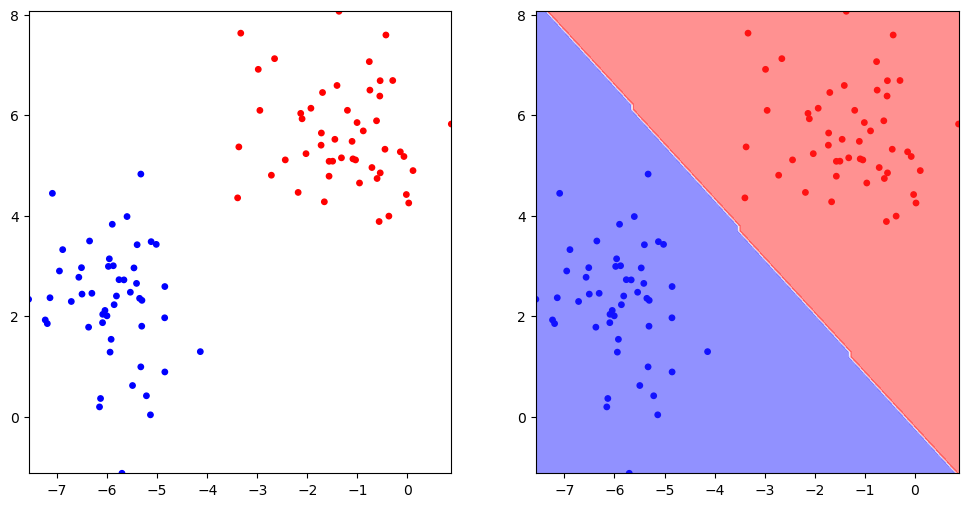

In [33]:
input_dim, output_dim = x.shape[1], y.shape[1]

# insira sua rede aqui!
nn = NeuralNetwork(cost_func=binary_cross_entropy, learning_rate=1e-1)
nn.layers.append(Layer(input_dim=input_dim, output_dim=output_dim, activation=sigmoid))
nn.fit(x, y, epochs=1000, verbose=100)

y_pred = nn.predict(x)

threshold = 0 if nn.layers[-1].activation == linear else 0.5
print('Acurácia: {:.2f}%'.format(100*accuracy_score(y, y_pred >= threshold)))
plot.classification_predictions(x, y, is_binary=True, nn=nn, threshold=threshold, cmap='bwr')

### 4 Clusters

(500, 2) (500, 1)


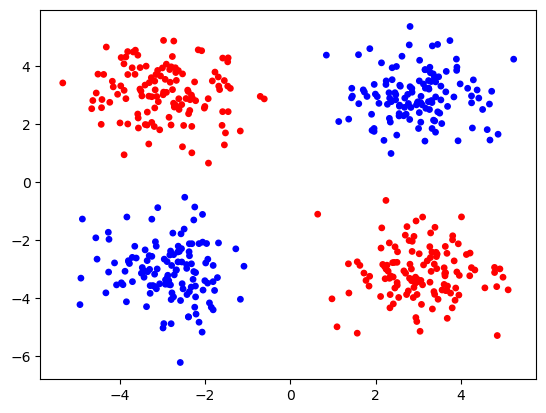

In [34]:
x, y = make_blobs(n_samples=500, n_features=2, cluster_std=0.9, centers=[(-3, -3), (3, 3), (-3, 3), (3, -3)], random_state=1234)
y = y.reshape(-1, 1)
y = np.where(y >= 2, 1, 0)

print(x.shape, y.shape)
plt.scatter(x[:,0], x[:,1], c=list(np.array(y).ravel()), s=15, cmap='bwr')

epoch:    0/1000 loss_train: 2.74054141
epoch:  100/1000 loss_train: 0.02423298
epoch:  200/1000 loss_train: 0.01176686
epoch:  300/1000 loss_train: 0.00791706
epoch:  400/1000 loss_train: 0.00603639
epoch:  500/1000 loss_train: 0.00492327
epoch:  600/1000 loss_train: 0.00418309
epoch:  700/1000 loss_train: 0.00365174
epoch:  800/1000 loss_train: 0.00324987
epoch:  900/1000 loss_train: 0.00293476
epoch: 1000/1000 loss_train: 0.00268065
Acurácia: 100.00%


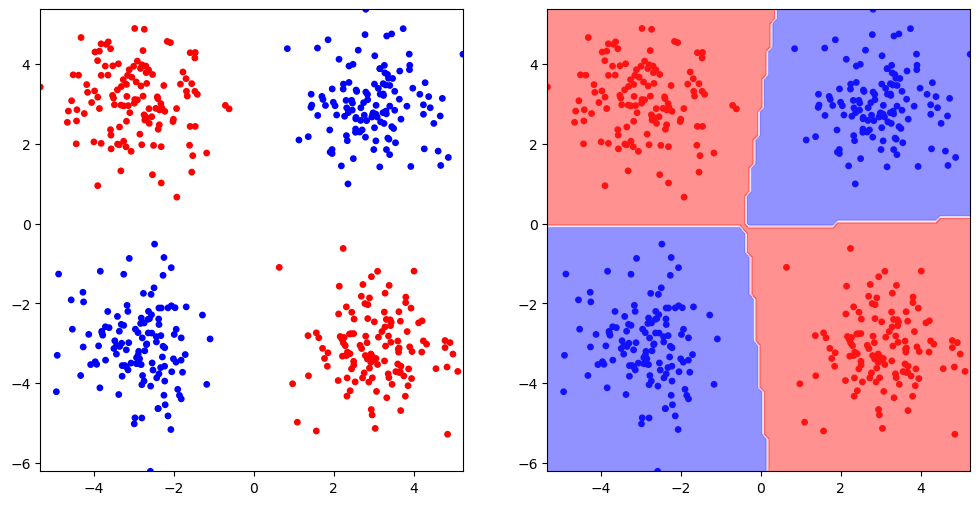

In [40]:
input_dim, output_dim = x.shape[1], y.shape[1]

# insira sua rede aqui!
nn = NeuralNetwork(cost_func=binary_cross_entropy, learning_rate=1e-1)
nn.layers.append(Layer(input_dim=input_dim, output_dim=4, activation=relu))
nn.layers.append(Layer(input_dim=4, output_dim=output_dim, activation=sigmoid))
nn.fit(x, y, epochs=1000, verbose=100)

y_pred = nn.predict(x)
print('Acurácia: {:.2f}%'.format(100*accuracy_score(y, y_pred > 0.5)))

plot.classification_predictions(x, y, is_binary=True, nn=nn, threshold=0.5, cmap='bwr')

### Círculos

(500, 2) (500, 1)


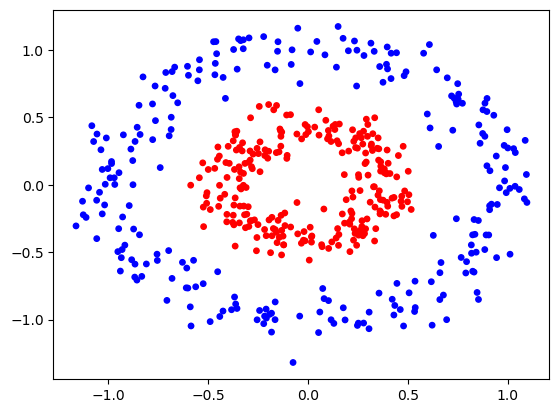

In [41]:
x, y = make_circles(n_samples=500, noise=0.1, factor=0.4, random_state=1234)
y = y.reshape(-1, 1)

print(x.shape, y.shape)
plt.scatter(x[:,0], x[:,1], c=list(np.array(y).ravel()), s=15, cmap='bwr')

epoch:    0/2000 loss_train: 1.10732654
epoch:  100/2000 loss_train: 0.29787095
epoch:  200/2000 loss_train: 0.14863947
epoch:  300/2000 loss_train: 0.08552497
epoch:  400/2000 loss_train: 0.05656671
epoch:  500/2000 loss_train: 0.04097362
epoch:  600/2000 loss_train: 0.03146743
epoch:  700/2000 loss_train: 0.02521552
epoch:  800/2000 loss_train: 0.02089062
epoch:  900/2000 loss_train: 0.01774660
epoch: 1000/2000 loss_train: 0.01532986
epoch: 1100/2000 loss_train: 0.01349156
epoch: 1200/2000 loss_train: 0.01204236
epoch: 1300/2000 loss_train: 0.01086929
epoch: 1400/2000 loss_train: 0.00989911
epoch: 1500/2000 loss_train: 0.00907909
epoch: 1600/2000 loss_train: 0.00838290
epoch: 1700/2000 loss_train: 0.00778443
epoch: 1800/2000 loss_train: 0.00726429
epoch: 1900/2000 loss_train: 0.00680797
epoch: 2000/2000 loss_train: 0.00640407
Acurácia: 100.00%


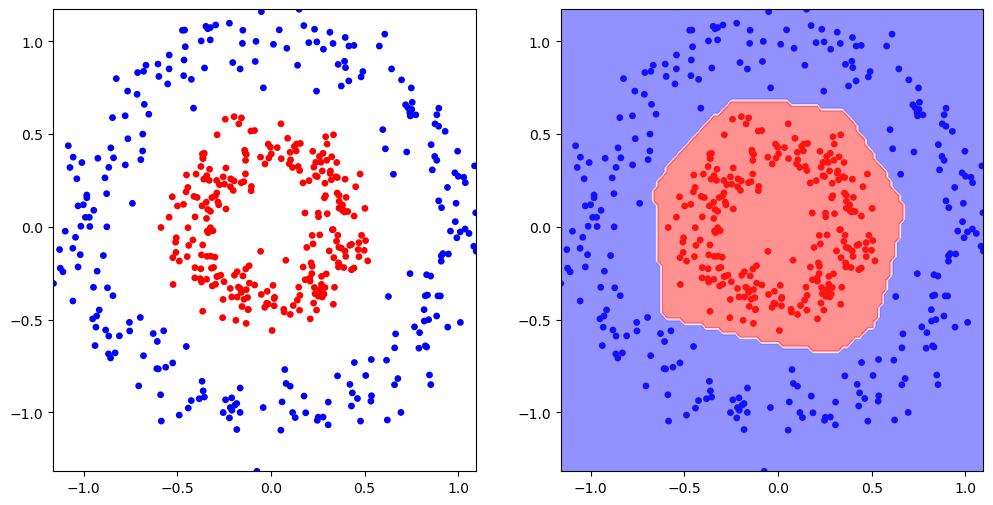

In [43]:
input_dim, output_dim = x.shape[1], y.shape[1]

# insira sua rede aqui!
nn = NeuralNetwork(cost_func=binary_cross_entropy, learning_rate=1e-1)
nn.layers.append(Layer(input_dim=input_dim, output_dim=10, activation=relu))
nn.layers.append(Layer(input_dim=10, output_dim=10, activation=tanh))
nn.layers.append(Layer(input_dim=10, output_dim=output_dim, activation=sigmoid))
nn.fit(x, y, epochs=2000, verbose=100)

y_pred = nn.predict(x)
print('Acurácia: {:.2f}%'.format(100*accuracy_score(y, y_pred > 0.5)))

plot.classification_predictions(x, y, is_binary=True, nn=nn, threshold=0.5, cmap='bwr')

### Moons

(200, 2) (200, 1)


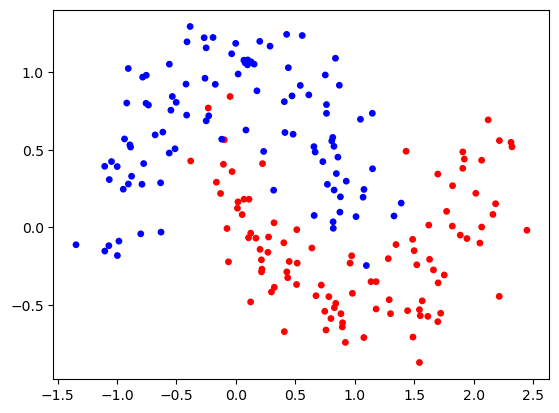

In [44]:
x, y = make_moons(200, noise=0.20)
y = y.reshape(-1, 1)

print(x.shape, y.shape)
plt.scatter(x[:,0], x[:,1], c=list(np.array(y).ravel()), s=15, cmap='bwr')

epoch:    0/2000 loss_train: 1.14086848
epoch:  100/2000 loss_train: 0.17506978
epoch:  200/2000 loss_train: 0.11598968
epoch:  300/2000 loss_train: 0.10062416
epoch:  400/2000 loss_train: 0.09368059
epoch:  500/2000 loss_train: 0.08950874
epoch:  600/2000 loss_train: 0.08634195
epoch:  700/2000 loss_train: 0.08311725
epoch:  800/2000 loss_train: 0.07984911
epoch:  900/2000 loss_train: 0.07740618
epoch: 1000/2000 loss_train: 0.07558849
epoch: 1100/2000 loss_train: 0.07386066
epoch: 1200/2000 loss_train: 0.07239076
epoch: 1300/2000 loss_train: 0.07094774
epoch: 1400/2000 loss_train: 0.06968419
epoch: 1500/2000 loss_train: 0.06853893
epoch: 1600/2000 loss_train: 0.06738508
epoch: 1700/2000 loss_train: 0.06669427
epoch: 1800/2000 loss_train: 0.06602764
epoch: 1900/2000 loss_train: 0.06523840
epoch: 2000/2000 loss_train: 0.06540769
Acurácia: 97.00%


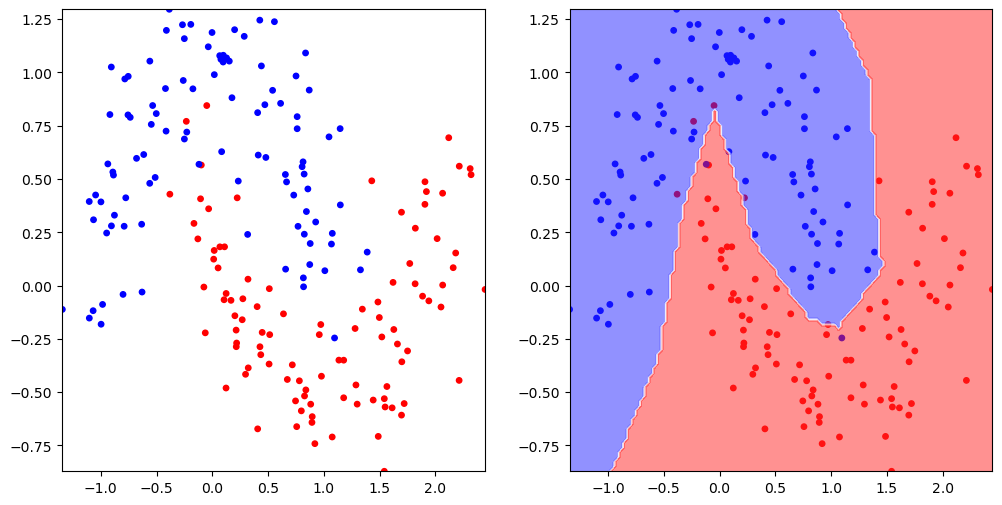

In [65]:
input_dim, output_dim = x.shape[1], y.shape[1]

# insira sua rede aqui!
nn = NeuralNetwork(cost_func=binary_cross_entropy, learning_rate=1.0)
nn.layers.append(Layer(input_dim=input_dim, output_dim=8, activation=relu))
nn.layers.append(Layer(input_dim=8, output_dim=output_dim, activation=sigmoid))

nn.fit(x, y, epochs=2000, verbose=100)

y_pred = nn.predict(x)
print('Acurácia: {:.2f}%'.format(100*accuracy_score(y, y_pred > 0.5)))

plot.classification_predictions(x, y, is_binary=True, nn=nn, threshold=0.5, cmap='bwr')

### Espiral

(200, 2) (200, 1)


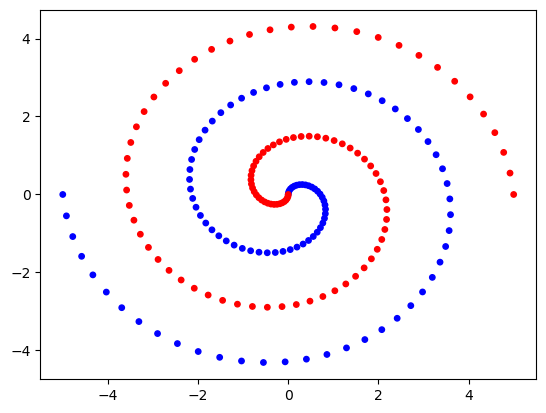

In [27]:
x, y = make_spiral(n_samples=100, n_class=2, radius=5, laps=1.75)
y = y.reshape(-1, 1)

print(x.shape, y.shape)
plt.scatter(x[:,0], x[:,1], c=list(np.array(y).ravel()), s=15, cmap='bwr')

epoch:    0/5000 loss_train: 12.38471347 + 0.00000000 = 12.38471347 loss_val = 12.38471347
epoch: 1000/5000 loss_train: 0.03252770 + 0.00000000 = 0.03252770 loss_val = 0.03252770
epoch: 2000/5000 loss_train: 0.01600321 + 0.00000000 = 0.01600321 loss_val = 0.01600321
epoch: 3000/5000 loss_train: 0.01256553 + 0.00000000 = 0.01256553 loss_val = 0.01256553
epoch: 4000/5000 loss_train: 0.01096151 + 0.00000000 = 0.01096151 loss_val = 0.01096151
epoch: 5000/5000 loss_train: 0.01005430 + 0.00000000 = 0.01005430 loss_val = 0.01005430
Acurácia: 99.50%


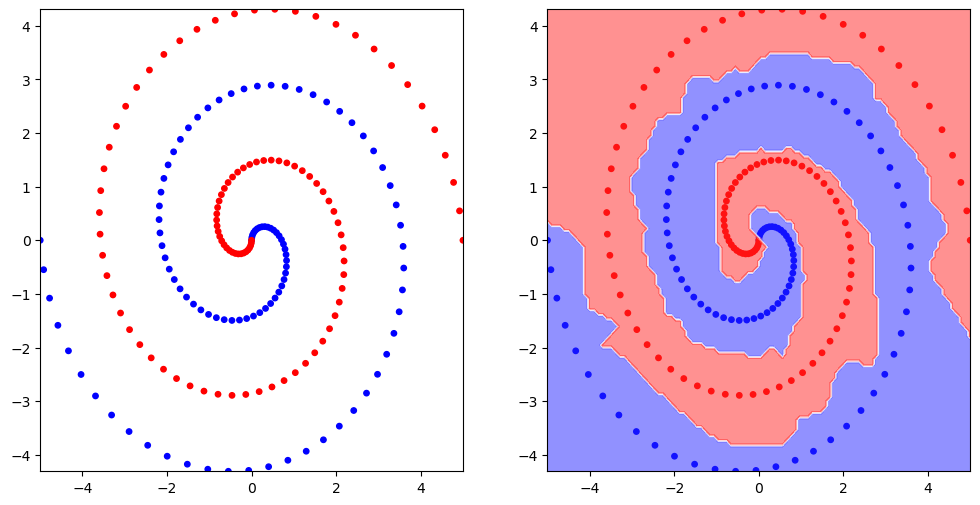

In [40]:
input_dim, output_dim = x.shape[1], y.shape[1]

# insira sua rede aqui!
nn = NeuralNetwork(cost_func=binary_cross_entropy, learning_rate=1e-1)
nn.layers.append(Layer(input_dim=input_dim, output_dim=20, activation=tanh))
nn.layers.append(Layer(input_dim=20, output_dim=20, activation=relu, batch_norm=True))
nn.layers.append(Layer(input_dim=20, output_dim=output_dim, batch_norm=True, activation=sigmoid))

nn.fit(x, y, epochs=5000, verbose=1000)

y_pred = nn.predict(x)
print('Acurácia: {:.2f}%'.format(100*accuracy_score(y, y_pred > 0.5)))

plot.classification_predictions(x, y, is_binary=True, nn=nn, threshold=0.5, cmap='bwr')

## Classificação Multiclasse

### 3 Clusters Multiclasse

(300, 2) (300, 1)


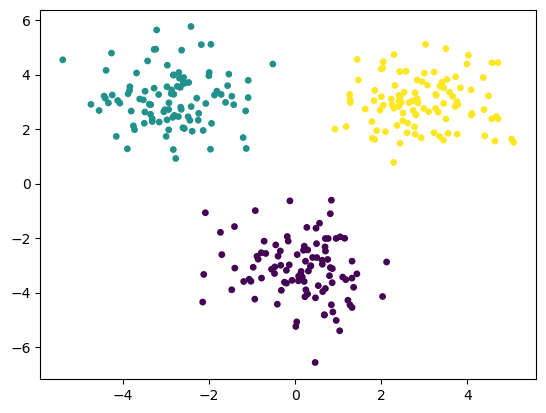

In [8]:
x, y = make_blobs(n_samples=300, n_features=2, centers=[(0, -3), (-3, 3), (3, 3)], random_state=1234)
y = y.reshape(-1, 1)

print(x.shape, y.shape)
plt.scatter(x[:,0], x[:,1], c=list(np.array(y).ravel()), s=15, cmap=plt.cm.viridis)

In [10]:
onehot = OneHotEncoder(sparse_output=False)
y_onehot = onehot.fit_transform(y)
print(y_onehot[::60])

[[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]


epoch:    0/1000 loss_train: 1.86493059
epoch:  100/1000 loss_train: 0.16308827
epoch:  200/1000 loss_train: 0.07328874
epoch:  300/1000 loss_train: 0.04671213
epoch:  400/1000 loss_train: 0.03401189
epoch:  500/1000 loss_train: 0.02649712
epoch:  600/1000 loss_train: 0.02152002
epoch:  700/1000 loss_train: 0.01800486
epoch:  800/1000 loss_train: 0.01540708
epoch:  900/1000 loss_train: 0.01341727
epoch: 1000/1000 loss_train: 0.01185329
Acurácia: 100.00%


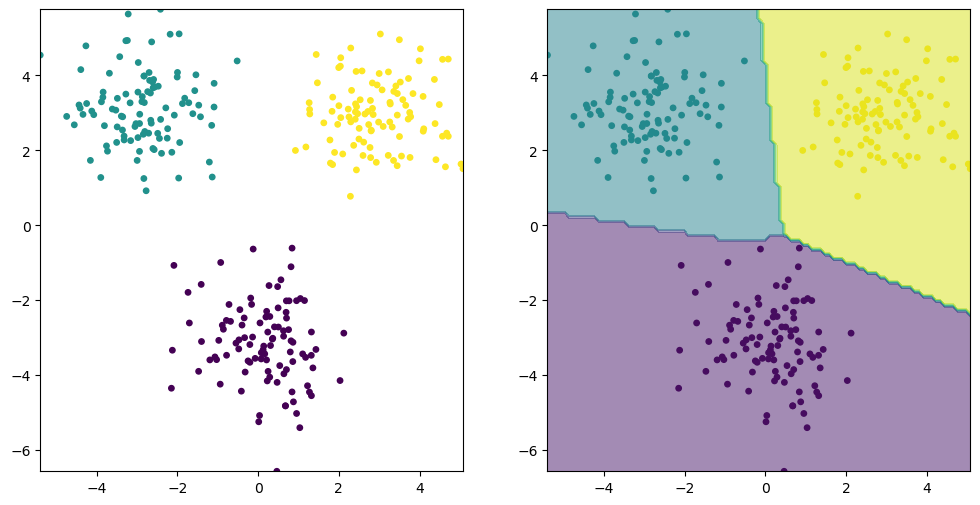

In [14]:
input_dim, output_dim = x.shape[1], y_onehot.shape[1]

# insira sua rede aqui!
nn = NeuralNetwork(cost_func=softmax_neg_log_likelihood, learning_rate=1e-1)
nn.layers.append(Layer(input_dim=input_dim, output_dim=2, activation=relu))
nn.layers.append(Layer(input_dim=2, output_dim=output_dim, activation=linear))

nn.fit(x, y_onehot, epochs=1000, verbose=100)

y_pred = np.argmax(nn.predict(x), axis=1)
print('Acurácia: {:.2f}%'.format(100*accuracy_score(y, y_pred)))

plot.classification_predictions(x, y, is_binary=False, nn=nn)

### 4 Clusters Multiclasse

(400, 2) (400, 1)


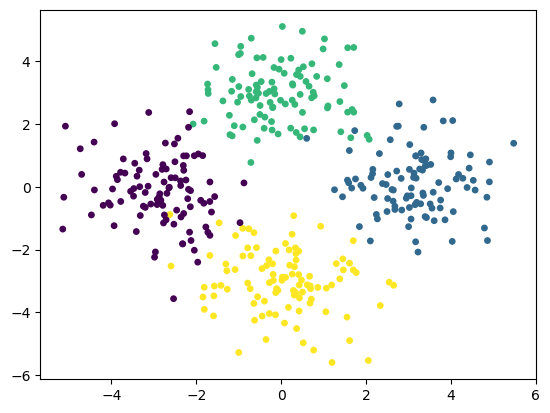

In [15]:
x, y = make_blobs(n_samples=400, n_features=2, centers=[(-3, 0), (3, 0), (0, 3), (0, -3)], random_state=1234)
y = y.reshape(-1, 1)

print(x.shape, y.shape)
plt.scatter(x[:,0], x[:,1], c=list(np.array(y).ravel()), s=15, cmap=plt.cm.viridis)

In [17]:
onehot = OneHotEncoder(sparse_output=False)
y_onehot = onehot.fit_transform(y)
print(y_onehot[::70])

[[0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]


epoch:    0/1000 loss_train: 3.55201866
epoch:  100/1000 loss_train: 0.29802518
epoch:  200/1000 loss_train: 0.15999174
epoch:  300/1000 loss_train: 0.12358498
epoch:  400/1000 loss_train: 0.10849369
epoch:  500/1000 loss_train: 0.10057143
epoch:  600/1000 loss_train: 0.09573462
epoch:  700/1000 loss_train: 0.09247618
epoch:  800/1000 loss_train: 0.09012556
epoch:  900/1000 loss_train: 0.08834170
epoch: 1000/1000 loss_train: 0.08682004
Acurácia: 97.25%


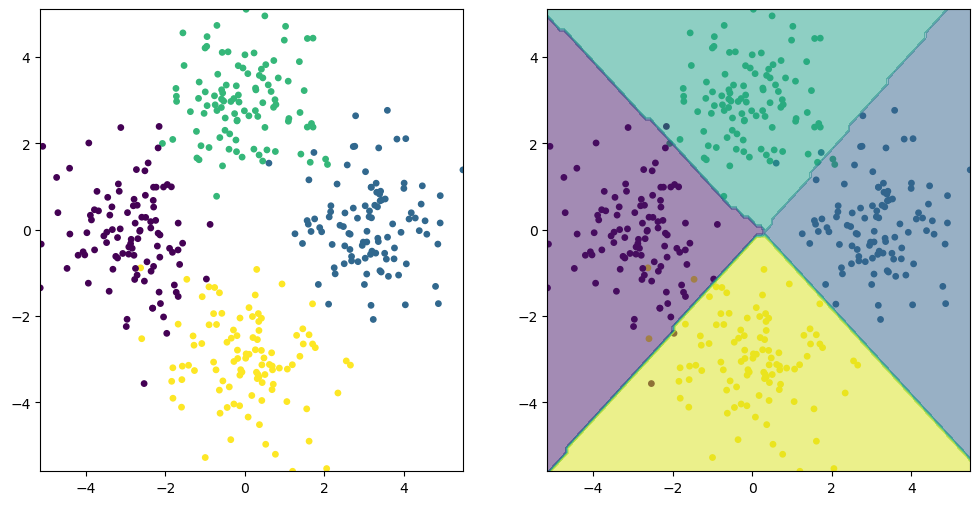

In [18]:
input_dim, output_dim = x.shape[1], y_onehot.shape[1]

# insira sua rede aqui!
nn = NeuralNetwork(cost_func=softmax_neg_log_likelihood, learning_rate=1e-1)
nn.layers.append(Layer(input_dim=input_dim, output_dim=3, activation=relu))
nn.layers.append(Layer(input_dim=3, output_dim=output_dim, activation=linear))

nn.fit(x, y_onehot, epochs=1000, verbose=100)

y_pred = np.argmax(nn.predict(x), axis=1)
print('Acurácia: {:.2f}%'.format(100*accuracy_score(y, y_pred)))

plot.classification_predictions(x, y, is_binary=False, nn=nn)

### Espiral - 5 Classes

(500, 2) (500, 1)


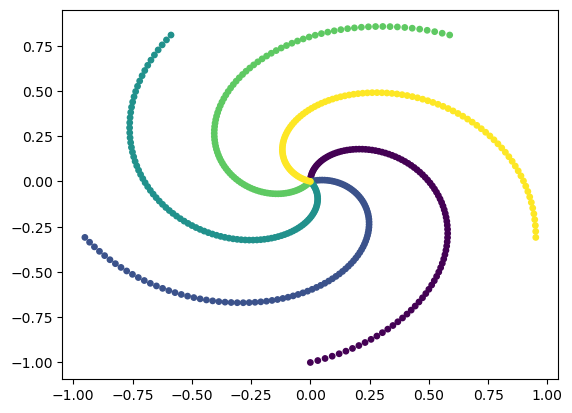

In [19]:
x, y = make_spiral(n_samples=100, n_class=5, radius=1, laps=0.5)
y = y.reshape(-1, 1)

print(x.shape, y.shape)
plt.scatter(x[:,0], x[:,1], c=list(np.array(y).ravel()), s=15, cmap=plt.cm.viridis)

In [21]:
onehot = OneHotEncoder(sparse_output=False)
y_onehot = onehot.fit_transform(y)
print(y_onehot[::100])

[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


epoch:    0/2000 loss_train: 6.65058364
epoch:  100/2000 loss_train: 1.14430662
epoch:  200/2000 loss_train: 0.90205260
epoch:  300/2000 loss_train: 0.79052448
epoch:  400/2000 loss_train: 0.69606477
epoch:  500/2000 loss_train: 0.60781650
epoch:  600/2000 loss_train: 0.53046145
epoch:  700/2000 loss_train: 0.46058609
epoch:  800/2000 loss_train: 0.40645174
epoch:  900/2000 loss_train: 0.33933954
epoch: 1000/2000 loss_train: 0.28185477
epoch: 1100/2000 loss_train: 0.25602586
epoch: 1200/2000 loss_train: 0.21899269
epoch: 1300/2000 loss_train: 0.19479241
epoch: 1400/2000 loss_train: 0.17575010
epoch: 1500/2000 loss_train: 0.15900313
epoch: 1600/2000 loss_train: 0.14552090
epoch: 1700/2000 loss_train: 0.13353930
epoch: 1800/2000 loss_train: 0.12412017
epoch: 1900/2000 loss_train: 0.11597341
epoch: 2000/2000 loss_train: 0.10897273
Acurácia: 97.40%


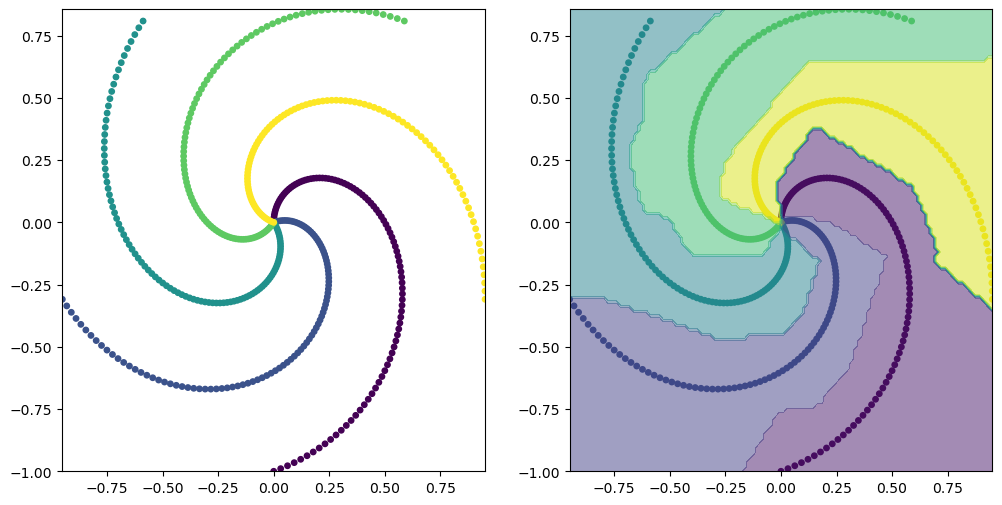

In [22]:
input_dim, output_dim = x.shape[1], y_onehot.shape[1]

# insira sua rede aqui!
nn = NeuralNetwork(cost_func=softmax_neg_log_likelihood, learning_rate=1e-1)
nn.layers.append(Layer(input_dim=input_dim, output_dim=10, activation=relu))
nn.layers.append(Layer(input_dim=10, output_dim=10, activation=relu))
nn.layers.append(Layer(input_dim=10, output_dim=output_dim, activation=linear))

nn.fit(x, y_onehot, epochs=2000, verbose=100)

y_pred = np.argmax(nn.predict(x), axis=1)
print('Acurácia: {:.2f}%'.format(100*accuracy_score(y, y_pred)))

plot.classification_predictions(x, y, is_binary=False, nn=nn)

### Make Classification - 4 Classes

(100, 2) (100, 1)


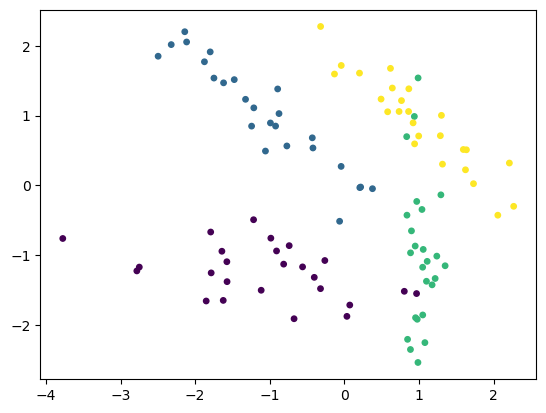

In [39]:
x, y = make_classification(n_samples=100, n_classes=4, n_features=2, n_clusters_per_class=1, n_redundant=0, n_repeated=0, random_state=1234)
y = y.reshape(-1, 1)

print(x.shape, y.shape)
plt.scatter(x[:,0], x[:,1], c=list(np.array(y).ravel()), s=15, cmap=plt.cm.viridis)

In [40]:
onehot = OneHotEncoder(sparse_output=False)
y_onehot = onehot.fit_transform(y)
print(y_onehot[::10])

[[0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]]


epoch:    0/1000 loss_train: 2.29065727
epoch:  100/1000 loss_train: 0.49800615
epoch:  200/1000 loss_train: 0.44793336
epoch:  300/1000 loss_train: 0.43709481
epoch:  400/1000 loss_train: 0.43428598
epoch:  500/1000 loss_train: 0.43359394
epoch:  600/1000 loss_train: 0.43342155
epoch:  700/1000 loss_train: 0.43337849
epoch:  800/1000 loss_train: 0.43336773
epoch:  900/1000 loss_train: 0.43336504
epoch: 1000/1000 loss_train: 0.43336436
Acurácia: 85.00%


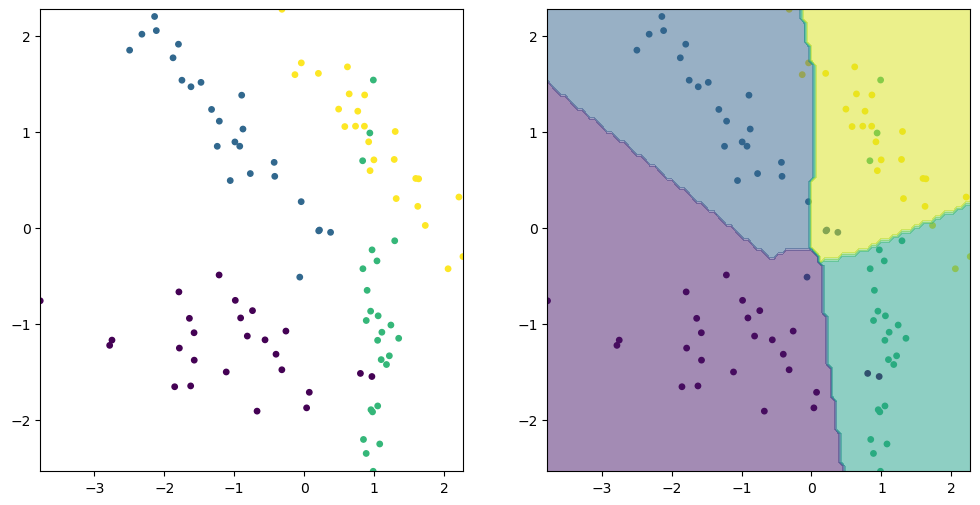

In [46]:
input_dim, output_dim = x.shape[1], y_onehot.shape[1]

# insira sua rede aqui!
nn = NeuralNetwork(cost_func=softmax_neg_log_likelihood, learning_rate=1e-1, lr_decay_method=staircase_decay, lr_decay_rate=0.5, lr_decay_steps=50)
nn.layers.append(Layer(input_dim=input_dim, output_dim=5, activation=relu))
nn.layers.append(Layer(input_dim=5, output_dim=output_dim, activation=linear))

nn.fit(x, y_onehot, epochs=1000, verbose=100)

y_pred = np.argmax(nn.predict(x), axis=1)
print('Acurácia: {:.2f}%'.format(100*accuracy_score(y, y_pred)))

plot.classification_predictions(x, y, is_binary=False, nn=nn)

### Iris Dataset

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']
(150, 2) (150, 1)


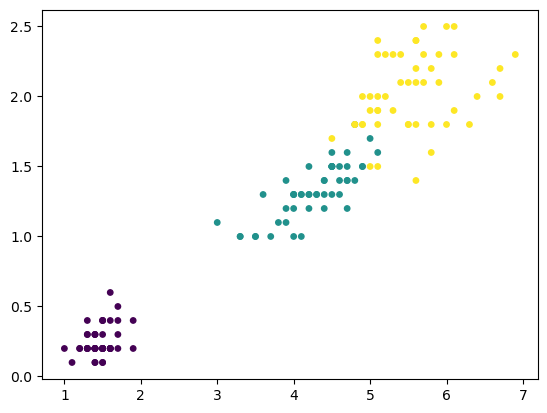

In [25]:
data = load_iris()
x, y = data.data[:, 2:], data.target.reshape(-1,1)

print(data.feature_names)
print(data.target_names)
print(x.shape, y.shape)
plt.scatter(x[:,0], x[:,1], c=list(np.array(y).ravel()), s=15, cmap=plt.cm.viridis)

In [26]:
onehot = OneHotEncoder(sparse_output=False)
y_onehot = onehot.fit_transform(y)
print(y_onehot[::20])

[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]


epoch:    0/1000 loss_train: 1.02549502
epoch:  100/1000 loss_train: 0.15920368
epoch:  200/1000 loss_train: 0.10337984
epoch:  300/1000 loss_train: 0.08750216
epoch:  400/1000 loss_train: 0.10704979
epoch:  500/1000 loss_train: 0.10908620
epoch:  600/1000 loss_train: 0.09123273
epoch:  700/1000 loss_train: 0.10754910
epoch:  800/1000 loss_train: 0.07231549
epoch:  900/1000 loss_train: 0.11386454
epoch: 1000/1000 loss_train: 0.08012635
Acurácia: 96.67%


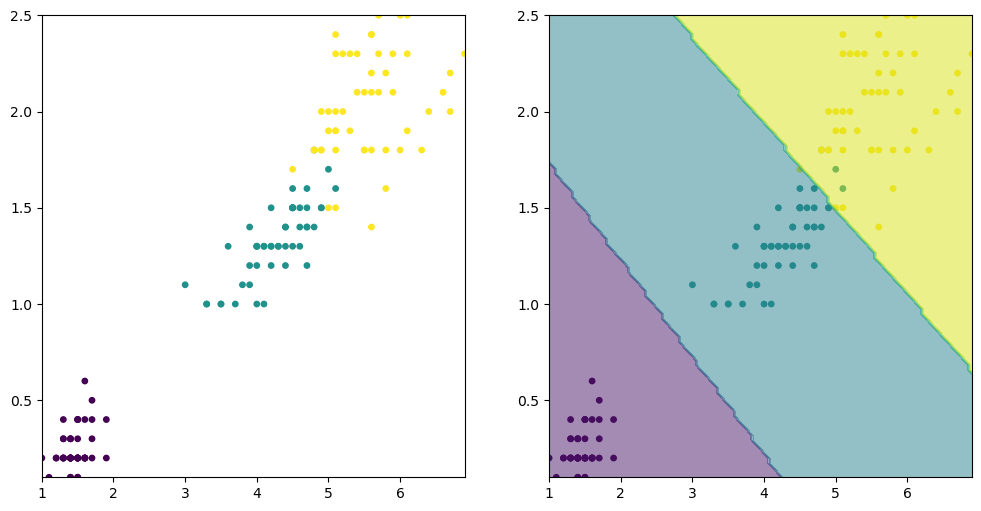

In [31]:
input_dim, output_dim = x.shape[1], y_onehot.shape[1]

# insira sua rede aqui!
nn = NeuralNetwork(cost_func=softmax_neg_log_likelihood, learning_rate=1e-1)
nn.layers.append(Layer(input_dim=input_dim, output_dim=5, activation=relu))
nn.layers.append(Layer(input_dim=5, output_dim=output_dim, activation=linear))

nn.fit(x, y_onehot, epochs=1000, verbose=100, batch_gen=batch_shuffle, batch_size=15)
#batch size -> 1:stochastic GD, None:batch GD, x>1:mini-bacth GD 

y_pred = np.argmax(nn.predict(x), axis=1)
print('Acurácia: {:.2f}%'.format(100*accuracy_score(y, y_pred)))

plot.classification_predictions(x, y, is_binary=False, nn=nn)

# [Link para o Questionário](https://docs.google.com/forms/d/e/1FAIpQLSf1B3JKsPPPc1oYD_3FyX4UvNLpcXnTW2I177A_WE0_B56Elw/viewform?usp=sf_link)

# Referências

- [Tensorflow Playground](http://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.94880&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false)

- [Linear Classification](http://cs231n.github.io/linear-classify/)

__Regularization__:
- [Implementing Neural Network L1 Regularization](https://jamesmccaffrey.wordpress.com/2017/06/27/implementing-neural-network-l1-regularization/)
- [Implementing Neural Network L2 Regularization](https://jamesmccaffrey.wordpress.com/2017/06/29/implementing-neural-network-l2-regularization/)
- [Neural Network L2 Regularization Using Python](https://visualstudiomagazine.com/articles/2017/09/01/neural-network-l2.aspx)

__Momentum__:
- [Neural Network Momentum Using Python](https://visualstudiomagazine.com/articles/2017/08/01/neural-network-momentum.aspx)
- [Beyond SGD: Gradient Descent with Momentum and Adaptive Learning Rate](https://wiseodd.github.io/techblog/2016/06/22/nn-optimization/)

__Learning Rate Decay__:
- [Using Learning Rate Schedules for Deep Learning Models in Python with Keras](https://machinelearningmastery.com/using-learning-rate-schedules-deep-learning-models-python-keras/)
- [Learning Rate Schedules and Adaptive Learning Rate Methods for Deep Learning](https://towardsdatascience.com/learning-rate-schedules-and-adaptive-learning-rate-methods-for-deep-learning-2c8f433990d1)
- [Tensorflow Exponential Decay Documentation](https://www.tensorflow.org/api_docs/python/tf/train/exponential_decay)

__Batch Normalization__:
- [Understanding the backward pass through Batch Normalization Layer](https://kratzert.github.io/2016/02/12/understanding-the-gradient-flow-through-the-batch-normalization-layer.html)
- [Deriving the Gradient for the Backward Pass of Batch Normalization](https://kevinzakka.github.io/2016/09/14/batch_normalization/)
- [Implementing BatchNorm in Neural Net](https://wiseodd.github.io/techblog/2016/07/04/batchnorm/)
- [What does the gradient flowing through batch normalization looks like ?](http://cthorey.github.io./backpropagation/)
- [GRADIENTS, BATCH NORMALIZATION AND LAYER NORMALIZATION](https://theneuralperspective.com/2016/10/27/gradient-topics/)

__Gradient Checking__:
- [cs231n](https://github.com/cs231n/cs231n.github.io/blob/master/neural-networks-3.md#gradcheck)
- [Gradient checking and advanced optimization](http://ufldl.stanford.edu/wiki/index.php/Gradient_checking_and_advanced_optimization)
- [BatchNormalization fails gradient checking](https://github.com/torch/nn/issues/744)